In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
import tensorflow as tf

# تنظیمات اولیه
DATA_DIR = '../data/human-and-non-human/training_set'
IMG_SIZE = 96
BATCH_SIZE = 32

# تابع نرمال‌سازی سریع
def process_data(image, label):
    return image / 255.0, label

# ۱. بارگذاری و آماده‌سازی داده‌های آموزشی
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)
train_dataset = train_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ۲. بارگذاری و آماده‌سازی داده‌های اعتبارسنجی
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)
val_dataset = val_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("متغیرهای داده با موفقیت در این نوتبوک ساخته شدند.")

Found 8017 files belonging to 2 classes.
Using 6414 files for training.
Found 8017 files belonging to 2 classes.
Using 1603 files for validation.
متغیرهای داده با موفقیت در این نوتبوک ساخته شدند.


In [2]:
# ساختار شبکه عصبی سبک برای TinyML
model = models.Sequential([
    layers.InputLayer(input_shape=(96, 96, 1)), # ورودی سیاه‌سفید
    
    # لایه اول استخراج ویژگی
    layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # کاهش ابعاد به 48x48
    
    # لایه دوم
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # کاهش ابعاد به 24x24
    
    # لایه سوم (مهم برای کاهش شدید پارامترها)
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # کاهش ابعاد به 12x12
    
    # مسطح کردن داده‌ها برای لایه‌های تصمیم‌گیرنده
    layers.Flatten(),
    
    # لایه‌های متراکم (Dense)
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3), # خاموش کردن تصادفی نورون‌ها برای جلوگیری از حفظ کردن (Overfitting)
    layers.Dense(1, activation='sigmoid') # خروجی نهایی: 0 (غیر انسان) یا 1 (انسان)
])

# مشاهده تعداد پارامترها و حجم شبکه
model.summary()

c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        36,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,465 (158.07 KB)

 Trainable params: 40,465 (158.07 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='adam',
              loss='binary_crossentropy', # تابع خطای مخصوص مسائل دوکلاسه‌
              metrics=['accuracy'])

EPOCHS = 15

print("شروع فرآیند آموزش شبکه...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

شروع فرآیند آموزش شبکه...
Epoch 1/15


201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.8622 - loss: 0.3026 - val_accuracy: 0.9651 - val_loss: 0.1180
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9674 - loss: 0.0890 - val_accuracy: 0.9807 - val_loss: 0.0554
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0.9857 - val_loss: 0.0414
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9883 - loss: 0.0390 - val_accuracy: 0.9888 - val_loss: 0.0292
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9877 - loss: 0.0357 - val_accuracy: 0.9906 - val_loss: 0.0277
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9931 - val_loss: 0.0234
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9933 - loss: 0.0193 - val_accuracy: 0.9931 - val_loss: 0.0225
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9927 - loss: 0.0190 - val_accuracy: 0.9950

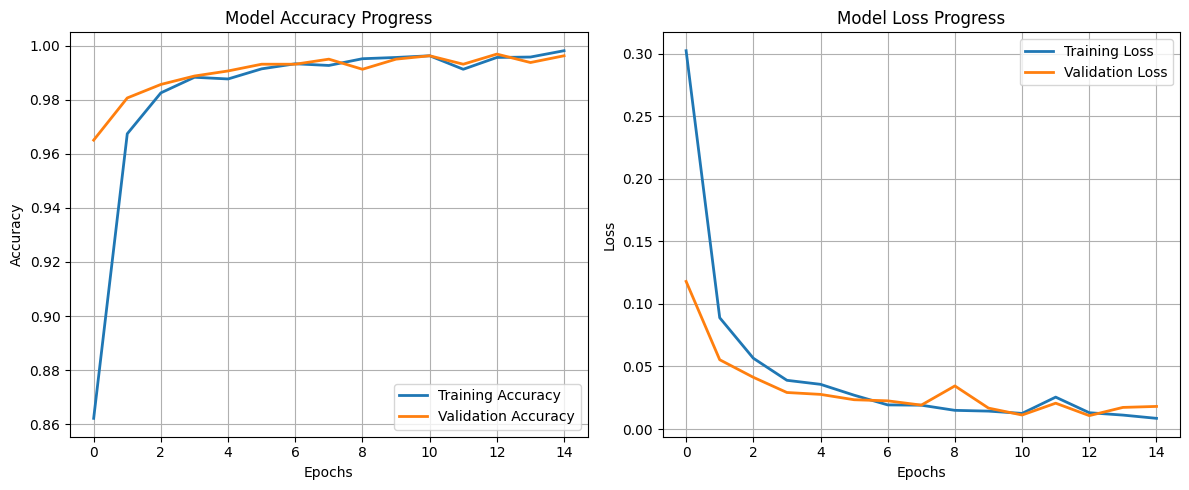

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# نمودار دقت (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# نمودار خطا (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
model.save('human_detection_base.keras')
print("مدل پایه با موفقیت ذخیره شد و آماده کوانتیزاسیون است.")

مدل پایه با موفقیت ذخیره شد و آماده کوانتیزاسیون است.
